# Zephyr vs Linux Kernel Git Analytics

This notebook compares **contributors** and **commits** between the Zephyr RTOS and Linux kernel repositories.

- **Contributors**: Unique contributors who committed in that calendar year (authors of commits in Jan 1–Dec 31)
- **Commits**: Total commits in that calendar year (Jan 1–Dec 31)

**Repo paths:**
- Linux: `~/Repositories/linux`
- Zephyr: Current workspace (or configured path)

**Year range:** 2016 through last complete year (current year excluded as incomplete)

In [1]:
import os
import subprocess
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
from tqdm import tqdm

# Repo paths (expand ~)
LINUX_REPO = os.path.expanduser("~/Repositories/linux")

# Zephyr repo: find project root (works when cwd is workspace or scripts/git_analytics)
def _find_zephyr_root() -> Path:
    cwd = Path.cwd()
    for candidate in [cwd, cwd.parent, cwd.parent.parent]:
        if (candidate / ".git").exists() and (candidate / "scripts").exists():
            return candidate
    return cwd

ZEPHYR_REPO = _find_zephyr_root()

# Years: 2016 through last complete year
from datetime import datetime
CURRENT_YEAR = datetime.now().year
YEARS = list(range(2016, CURRENT_YEAR))  # Exclude current year (incomplete)

print(f"Linux repo:  {LINUX_REPO}")
print(f"Zephyr repo: {ZEPHYR_REPO}")
print(f"Years: {YEARS[0]}–{YEARS[-1]}")

Linux repo:  /Users/kartben/Repositories/linux
Zephyr repo: /Users/kartben/zephyrproject/zephyr
Years: 2016–2025


In [2]:
def resolve_zephyr_repo(zephyr_path: Path) -> Path:
    """Resolve Zephyr repo path, trying worktrees if main repo lacks history."""
    zephyr_path = Path(zephyr_path)
    if not zephyr_path.exists():
        raise FileNotFoundError(f"Zephyr repo not found: {zephyr_path}")
    git_dir = zephyr_path / ".git"
    if not git_dir.exists():
        raise FileNotFoundError(f"Not a git repo: {zephyr_path}")
    # Try a simple git command to see if we have history
    try:
        subprocess.run(
            ["git", "-C", str(zephyr_path), "rev-list", "--count", "--until=2016-12-31", "HEAD"],
            capture_output=True,
            check=True,
            timeout=30,
        )
    except (subprocess.CalledProcessError, subprocess.TimeoutExpired):
        # Try worktrees
        result = subprocess.run(
            ["git", "-C", str(zephyr_path), "worktree", "list"],
            capture_output=True,
            text=True,
            encoding="utf-8",
            errors="replace",
            timeout=10,
        )
        if result.returncode == 0 and result.stdout.strip():
            # Use first worktree path (main)
            first_line = result.stdout.strip().split("\n")[0]
            wt_path = first_line.split()[0]
            return Path(wt_path)
        raise RuntimeError(
            f"Cannot get git history from {zephyr_path}. "
            "Ensure a full clone or use a worktree with full history."
        )
    return zephyr_path


def get_contributors_count(repo_path: Path, since: str, until: str) -> int:
    """Unique contributors who committed in the date range (since–until). Uses mailmap."""
    result = subprocess.run(
        [
            "git", "-C", str(repo_path),
            "log", "--use-mailmap", "--format=%aN", f"--since={since}", f"--until={until}", "HEAD",
        ],
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace",
        timeout=120,
    )
    if result.returncode != 0:
        return 0
    authors = {a.strip() for a in result.stdout.strip().split("\n") if a.strip()}
    return len(authors)


def get_commits_count(repo_path: Path, since: str, until: str) -> int:
    """Commits in calendar year (since–until)."""
    result = subprocess.run(
        [
            "git", "-C", str(repo_path),
            "rev-list", "--count", f"--since={since}", f"--until={until}", "HEAD",
        ],
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace",
        timeout=120,
    )
    if result.returncode != 0:
        return 0
    return int(result.stdout.strip() or 0)


def collect_repo_stats(repo_path: Path, years: list, pbar: tqdm, repo_name: str) -> tuple[dict, dict]:
    """Collect contributors and commits per year for a repo. Updates pbar as it goes."""
    contributors = {}
    commits = {}
    for y in years:
        until = f"{y}-12-31 23:59:59"
        since = f"{y}-01-01"
        contributors[y] = get_contributors_count(repo_path, since, until)
        commits[y] = get_commits_count(repo_path, since, until)
        pbar.update(1)
    return contributors, commits


# Resolve Zephyr path (may use worktree)
ZEPHYR_REPO = resolve_zephyr_repo(ZEPHYR_REPO)

if not Path(LINUX_REPO).exists():
    raise FileNotFoundError(f"Linux repo not found: {LINUX_REPO}")

# Run Linux and Zephyr collection in parallel with tqdm
linux_contributors = {}
linux_commits = {}
zephyr_contributors = {}
zephyr_commits = {}

with tqdm(total=len(YEARS), desc="Linux", position=0, leave=True) as pbar_linux, \
     tqdm(total=len(YEARS), desc="Zephyr", position=1, leave=True) as pbar_zephyr:
    with ThreadPoolExecutor(max_workers=2) as executor:
        future_linux = executor.submit(collect_repo_stats, Path(LINUX_REPO), YEARS, pbar_linux, "Linux")
        future_zephyr = executor.submit(collect_repo_stats, ZEPHYR_REPO, YEARS, pbar_zephyr, "Zephyr")
        linux_contributors, linux_commits = future_linux.result()
        zephyr_contributors, zephyr_commits = future_zephyr.result()

print("\nDone collecting stats.")

Linux:   0%|          | 0/10 [00:00<?, ?it/s]

Linux: 100%|██████████| 10/10 [01:17<00:00,  7.74s/it]


Done collecting stats.


In [3]:
# Build data for charts
years_list = YEARS
linux_contrib = [linux_contributors[y] for y in years_list]
zephyr_contrib = [zephyr_contributors[y] for y in years_list]
linux_comm = [linux_commits[y] for y in years_list]
zephyr_comm = [zephyr_commits[y] for y in years_list]

print("Contributors (unique per year):")
for y in years_list:
    print(f"  {y}: Linux={linux_contributors[y]}, Zephyr={zephyr_contributors[y]}")
print("\nCommits (per year):")
for y in years_list:
    print(f"  {y}: Linux={linux_commits[y]}, Zephyr={zephyr_commits[y]}")

Contributors (unique per year):
  2016: Linux=4042, Zephyr=159
  2017: Linux=4426, Zephyr=184
  2018: Linux=4381, Zephyr=275
  2019: Linux=4375, Zephyr=364
  2020: Linux=4629, Zephyr=472
  2021: Linux=4794, Zephyr=593
  2022: Linux=4926, Zephyr=665
  2023: Linux=4935, Zephyr=917
  2024: Linux=5100, Zephyr=1124
  2025: Linux=5325, Zephyr=1409

Commits (per year):
  2016: Linux=77063, Zephyr=11262
  2017: Linux=80851, Zephyr=6821
  2018: Linux=80340, Zephyr=8001
  2019: Linux=82523, Zephyr=9905
  2020: Linux=90440, Zephyr=11091
  2021: Linux=86105, Zephyr=11941
  2022: Linux=85816, Zephyr=14456
  2023: Linux=91290, Zephyr=15612
  2024: Linux=83280, Zephyr=18752
  2025: Linux=85486, Zephyr=21762


In [4]:
# Export raw data to CSV
import csv

OUTPUT_CSV = ZEPHYR_REPO / "scripts" / "git_analytics" / "zephyr_vs_linux_raw.csv"

with open(OUTPUT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["year", "linux_contributors", "zephyr_contributors", "linux_commits", "zephyr_commits"])
    for y in years_list:
        w.writerow([y, linux_contributors[y], zephyr_contributors[y], linux_commits[y], zephyr_commits[y]])

print(f"Raw data exported to: {OUTPUT_CSV}")

Raw data exported to: /Users/kartben/zephyrproject/zephyr/scripts/git_analytics/zephyr_vs_linux_raw.csv


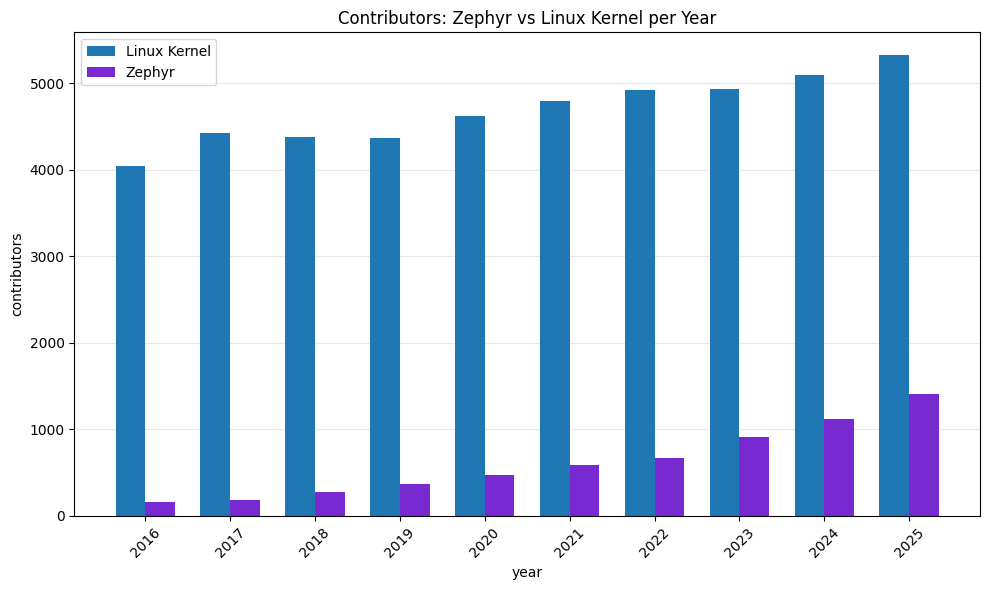

In [5]:
# Chart 1: Contributors per Year (Zephyr vs Linux)
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(years_list))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], linux_contrib, width, label="Linux Kernel", color="#1f77b4")
bars2 = ax.bar([i + width/2 for i in x], zephyr_contrib, width, label="Zephyr", color="#7929D2")

ax.set_xlabel("year")
ax.set_ylabel("contributors")
ax.set_title("Contributors: Zephyr vs Linux Kernel per Year")
ax.set_xticks(x)
ax.set_xticklabels(years_list, rotation=45)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

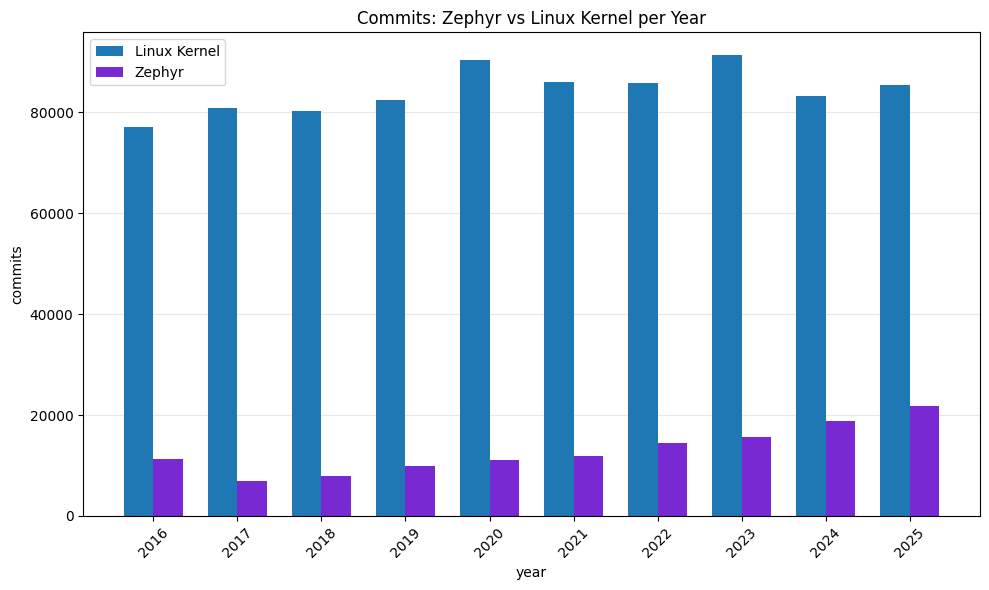

In [6]:
# Chart 2: Commits per Year (Zephyr vs Linux)
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(years_list))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], linux_comm, width, label="Linux Kernel", color="#1f77b4")
bars2 = ax.bar([i + width/2 for i in x], zephyr_comm, width, label="Zephyr", color="#7929D2")

ax.set_xlabel("year")
ax.set_ylabel("commits")
ax.set_title("Commits: Zephyr vs Linux Kernel per Year")
ax.set_xticks(x)
ax.set_xticklabels(years_list, rotation=45)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()